In [1]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

from rasterio.plot import plotting_extent

# Import necessary elevation functions

In [2]:
sys.path.append('../src/nlr_ghe_screen/processing/') 
from elevation import (
    clip_raster_to_shapes,
    reproject_elevation_data,
    calculate_slopes,
    summarize_stats,
    categorize_geometries
)

# Create plotting functions

In [3]:
def plot_shapes(idx, gdf, clips, title, vmin=None, vmax=None):
    arr, transform = clips[idx]
    fig, ax = plt.subplots(figsize=((8, 8)))

    extent = plotting_extent(arr, transform)
    im = ax.imshow(
        arr, 
        extent=extent, 
        cmap='terrain',
        vmin=vmin,
        vmax=vmax,
    )

    gdf.loc[[idx]].boundary.plot(
        ax=ax, 
        color="black", 
        linewidth=1.5
    )

    ax.set_title(f"Shape {idx}")
    plt.colorbar(im, ax=ax, label=title, shrink=0.8)
    plt.show()

In [4]:
def plot_data(raster_data, title, vmin=None, vmax=None):
    extent = plotting_extent(raster_data.read(1), raster_data.transform)
    fig, ax = plt.subplots(figsize=(12, 10))
    image = ax.imshow(
        raster_data.read(1),
        extent=extent,
        cmap="terrain",
        origin="upper",
        vmin=vmin,
        vmax=vmax,
    )

    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label(title)

    ax.set_title(f"Overall {title}")
    plt.show()

# Open and create necessary elevation / slope files

In [5]:
IMPORT_DIR = '../src/imports/'
EXPORT_DIR = '../src/exports/'

raster_src = rasterio.open(IMPORT_DIR + "elevation_data.tif")
gdf = gpd.read_file(EXPORT_DIR + "ghe_locations.geojson")

if gdf.crs != raster_src.crs:
    gdf = gdf.to_crs(raster_src.crs)

In [6]:
reproject_elevation_data(
    elevation_src=raster_src,
    dst_crs=gdf.estimate_utm_crs()
)
reproject_raster = rasterio.open(IMPORT_DIR + 'reprojected_elevation_data.tif')

slope = calculate_slopes(reproject_raster)
slope_raster_src = rasterio.open(IMPORT_DIR + 'slope.tif')

In [7]:
elevation_gdf, elevation_clips = clip_raster_to_shapes(raster_src, gdf)
slope_gdf, slope_clips = clip_raster_to_shapes(slope_raster_src, gdf.to_crs(gdf.estimate_utm_crs()).copy())

# Plot elevation / slope data

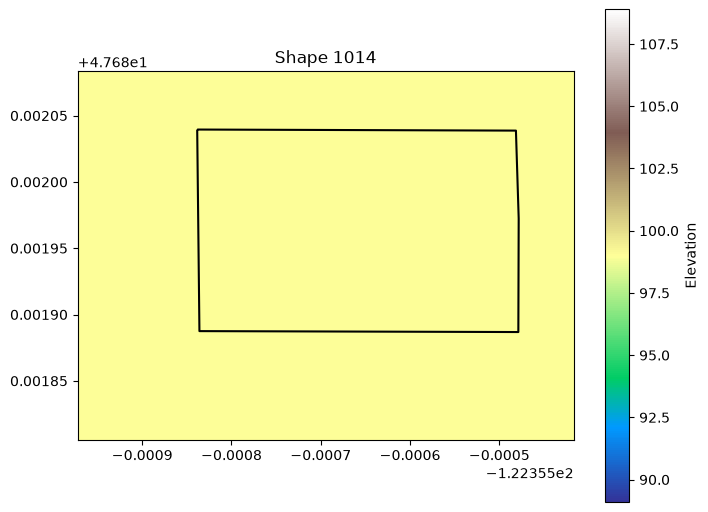

In [8]:
idx = 1014
plot_shapes(idx, elevation_gdf, elevation_clips, "Elevation")

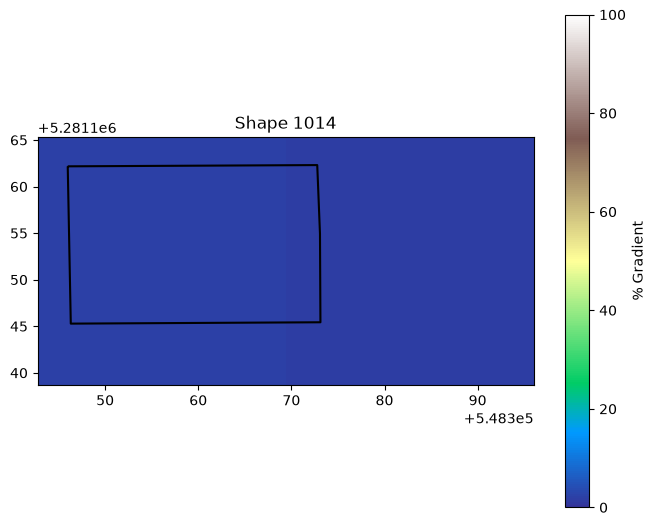

In [9]:
idx = 1014
plot_shapes(idx, slope_gdf, slope_clips, "% Gradient", vmin=0, vmax=100)

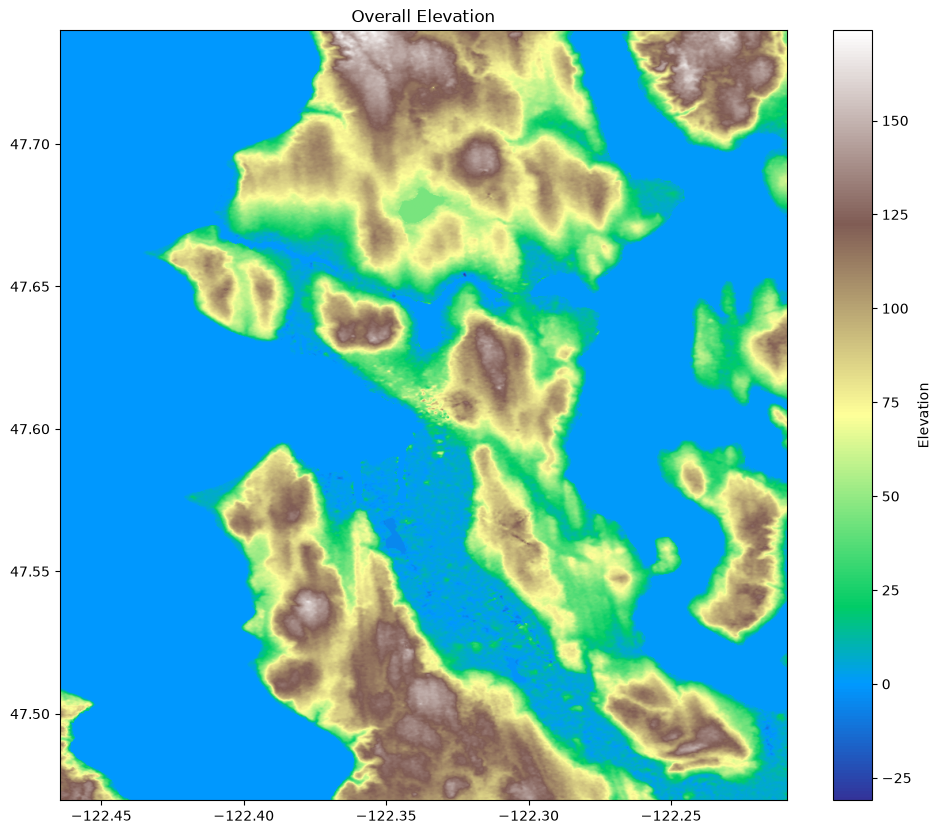

In [10]:
plot_data(raster_src, "Elevation")

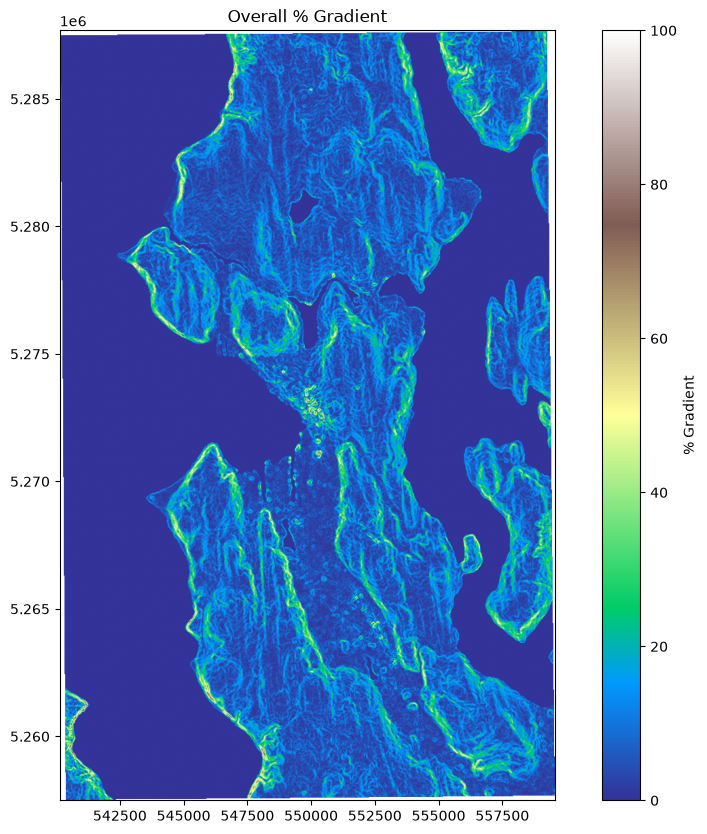

In [11]:
plot_data(slope_raster_src, "% Gradient", vmin=0, vmax=100)